# Sztuczna Inteligencja - Lista 2
## Mikołaj Kamiński 280596

# Cel
Celem listy było implementacja algorytmu MiniMax oraz implementacja cięć alfa-beta dla gry Breakthrough.
Algorytm MiniMax służy do przeszukiwania drzewa gry w celu znalezienie optymalnej pozycji, jako że ruchy graczy są wykonywane na przemiennie algorytm na przemian wybiera maximum (dla pozycji gdzie my wykonujemy ruch) oraz minimum (dla pozycji przeciwnika - zakładamy że przeciwnik będzie wykonywał najlepsze dla siebie ruchy). Liczba możliwych rozwiązań rośnie wykładniczo wraz z kolejnymi poziomami drzewa stąd na nasz algorytm będzie musieli nałożyć ograniczenie głębokości przeszukiwania. Ważna rolę pełnią w nim funkcje oceny stanu jako, że nieoptymalne heurystyki sprawią że nasz algorytm premiował będzie nieoptymalne pozycje, co końcowo doprowadzi go do porażki

# Implementacja gry
Implementacje gry podzieliłem na dwie części: 
- `game.py` - klasa `Game` odzwierciedlająca grę, służy jako "sędzia", wykonuje rzeczywiste ruchy na planszy, wysyła graczom informacje o aktualnym stanie, waliduje ruchy i loguje wyniki
- `player.py` - klasy odzwierciedlające graczy `BasePlayer` (agregowana przez Game) klasa bazowa, `HPlayer` klasa dla gracza ludzkiego, `CPlayer` klasa dla gracza sterowanego przez komputer, `RPlayer` klasa robiąca kompletnie losowe - kontrola dla działania heurystyk

In [ ]:
from __future__ import annotations
from player import BasePlayer, CPlayer, HPlayer
from logger import MatchResultsCsvWriter
from datetime import datetime
import time 


class Game: 
    def __init__(self, x_size: int , y_size: int, player1: BasePlayer, player2: BasePlayer, symbol1: str = 'W', symbol2: str = 'B', starting_player: str = 'W', results_logger: MatchResultsCsvWriter | None = None):
        self.p1: BasePlayer= player1
        self.p2: BasePlayer= player2
        self.x: int= x_size
        self.y: int= y_size
        self.symbol1: str = symbol1
        self.symbol2: str  = symbol2
        self.move_count: int = 0 
        self.board: list[list[chr]] = []
        self.finished: bool = False 
        self.results_logger = results_logger
        if starting_player not in [self.symbol1, self.symbol2]: 
            raise Exception("Starting player must either match symbol1 or symbol2")
        self.start_time: float = 0.0
        self.end_time : float = 0.0 
        self.starting_player = starting_player
        self.prepare_next_match()


    def reset_game(self, change_player_side: bool = False, resize_board: tuple[bool, int, int] = (False, 0, 0)):
        resize = None
        if resize_board[0]:
            resize = (resize_board[1], resize_board[2])
        self.prepare_next_match(swap_player_order=change_player_side, resize_board=resize)

    def prepare_next_match(self, swap_player_order: bool = False, resize_board: tuple[int, int] | None = None):
        if swap_player_order:
            self._swap_starting_player()
        if resize_board is not None:
            self.x = resize_board[0]
            self.y = resize_board[1]

        self._reset_runtime_state()
        self.init_board()
        self.set_player_sides()
        self.set_players()
        self._reset_players_runtime_state()

    def play_match_series(self, games_count: int, swap_player_order_each_game: bool = True, summary: bool = False, csv_data: bool = False) -> list[str]:
        if games_count <= 0:
            raise Exception("games_count should be greater than 0")

        winners: list[str] = []
        for game_idx in range(games_count):
            if game_idx > 0:
                self.prepare_next_match(swap_player_order=swap_player_order_each_game)
            winners.append(self.play_game(summary=summary, csv_data=csv_data))
        return winners

    def _reset_runtime_state(self):
        self.finished = False
        self.move_count = 0
        self.start_time = 0.0
        self.end_time = 0.0

    def _reset_players_runtime_state(self):
        self.p1.reset_state()
        self.p2.reset_state()

    def _swap_starting_player(self):
        self.starting_player = self.symbol2 if self.starting_player == self.symbol1 else self.symbol1


    def init_board(self):
        if self.x < 0 or self.y<4:
            raise Exception("x_size should be greater than 0, y_size should be greater or equal to 4")
        self.board = []
        for _ in range(2):
            tmp = [self.symbol1 for _ in range(self.x)]
            self.board.append(tmp) 

        for i in range(self.y-4):
             tmp = ['_' for i in range(self.x)]
             self.board.append(tmp)

        for _ in range(2):
            tmp = [self.symbol2 for _ in range(self.x)]
            self.board.append(tmp)
            
    def set_player_sides(self):
        if self.starting_player == self.symbol1:
            self.p1.set_side(self.symbol1)
            self.p2.set_side(self.symbol2)
        else:
            self.p1.set_side(self.symbol2)
            self.p2.set_side(self.symbol1)

    def set_players(self): 
        self.p1.set_x_size(self.x)
        self.p1.set_y_size(self.y)
        self.p1.set_opponent(self.symbol2 if self.p1.get_side() == self.symbol1 else self.symbol1)
        self.p1.set_direction(1 if self.p1.get_side() == self.symbol1 else -1)
        self.p2.set_x_size(self.x)
        self.p2.set_y_size(self.y)
        self.p2.set_opponent(self.symbol1 if self.p2.get_side() == self.symbol2 else self.symbol2)
        self.p2.set_direction(1 if self.p2.get_side() == self.symbol1 else -1)


    def configure_results_logger(self, results_logger: MatchResultsCsvWriter):
        self.results_logger = results_logger

    def check_move_legality(self, start_pos: tuple[int, int], end_pos: tuple[int, int], player_side: str) -> tuple[bool, str]:
        st_y, st_x = start_pos
        ed_y, ed_x = end_pos

        if not (0 <= st_x < self.x and 0 <= ed_x < self.x and 0 <= st_y < self.y and 0 <= ed_y < self.y):
            return False, "Współrzędne znajdują się poza planszą."

        if self.board[st_y][st_x] != player_side:
            return False, "Na wybranym polu startowym nie ma Twojego pionka."

        forward_step = 1 if player_side == self.symbol1 else -1

        dy = ed_y - st_y
        dx = ed_x - st_x

        if dy != forward_step:
            return False, "Pionki mogą poruszać się wyłącznie o jedno pole do przodu."

        if abs(dx) > 1:
            return False, "Pionek może poruszać się tylko prosto lub po skosie o jedno pole."

        target_cell = self.board[ed_y][ed_x]

        if dx == 0:
            if target_cell in [self.symbol1, self.symbol2]:
                return False, "Pole na wprost jest zajęte. Bicie możliwe jest tylko po skosie."
        
        else:
            if target_cell == player_side:
                return False, "Pole po skosie jest zajęte przez Twój własny pionek."
        return True, "Ruch dozwolony."
    
    def make_move(self, start_pos: tuple[int, int], end_pos: tuple[int, int])-> bool:
        symbol = self.board[start_pos[0]][start_pos[1]]
        self.board[start_pos[0]][start_pos[1]] = '_'
        self.board[end_pos[0]][end_pos[1]] = symbol
        
        # Check standard win condition (reaching the end)
        if (symbol == self.symbol1 and end_pos[0] == self.y - 1) or (symbol == self.symbol2 and end_pos[0] == 0):
            return True
            
        # Check if the opponent ran out of pawns
        opponent_symbol = self.symbol2 if symbol == self.symbol1 else self.symbol1
        opponent_has_pawns = any(opponent_symbol in row for row in self.board)
        
        return not opponent_has_pawns
    
    def play_game(self, summary: bool = False, csv_data: bool = False)-> str:
        curr_player  = self.p2 if self.symbol1 == self.starting_player else self.p1 
        other_player = self.p2 if curr_player == self.p1 else self.p1
        self.start_time = time.perf_counter()
        while not self.finished:
            curr_player, other_player = other_player, curr_player
            sx, sy, ex, ey, side =curr_player.handle_move(self.board)
            legal, reason = self.check_move_legality((sy, sx), (ey, ex), side)
            if not legal:  
                sx, sy, ex, ey, side= self.handle_incorrect_move(player=curr_player, reason=reason)
            self.finished = self.make_move((sy, sx),(ey, ex))
            self.move_count +=1
        self.end_time = time.perf_counter() 
        winner = curr_player
        if summary: 
            self.print_game_summary(winner)
        if self.results_logger is not None:
            self.results_logger.log_match_result(self._build_match_record(winner))
        elif csv_data:
            raise Exception("CSV logging requested but no results logger was configured.")
        return winner.get_side()

    def _build_match_record(self, winner: BasePlayer) -> dict[str, object]:
        p1_stats = self.p1.get_match_stats()
        p2_stats = self.p2.get_match_stats()
        winnerdata = winner.get_match_stats()
        record = {
            "timestamp": datetime.utcnow().isoformat(),
            "winner": winner.get_side(),
            "winner_heuristic": winnerdata.get("heuristic_name", ""),
            "move_count": self.move_count,
            "board_width": self.x,
            "board_height": self.y,
            "starting_player": self.starting_player,
            "player1_class": self.p1.__class__.__name__,
            "player1_side": self.p1.get_side(),
            "player1_heuristic": p1_stats.get("heuristic_name", ""),
            "player1_search_depth": p1_stats.get("search_depth", ""),
            "player2_class": self.p2.__class__.__name__,
            "player2_side": self.p2.get_side(),
            "player2_heuristic": p2_stats.get("heuristic_name", ""),
            "player2_search_depth": p2_stats.get("search_depth", ""),
            "player2_positions_evaluated": p2_stats.get("positions_evaluated", ""),
            "player1_positions_evaluated": p1_stats.get("positions_evaluated", ""), 
            "time_played": (str(self.end_time - self.start_time)+'s')
        }
        return self.results_logger.build_record(record) if self.results_logger is not None else record

    def print_game_summary(self, player: BasePlayer):
        print(30*"=")
        self.print_state()
        print(f"Zwycięzca: {player.get_side()}")
        print(f"Wygrana w {self.move_count} ruchach")
        print(f"Rozmiar planszy: {self.x}x{self.y}")
        print(30*"=")

    def print_state(self):
        print(f"\n--- Ustawienie ---")
        for i, row in enumerate(self.board): 
            print(f"{i} | " + " ".join(row))
        
        print("-" * (self.x * 2 + 4))
        print("    " + " ".join(str(i) for i in range(self.x)))
        print()

    def handle_incorrect_move(self, player: BasePlayer, reason: str)-> tuple[int, int, int, int, str]:
        if isinstance(player, HPlayer):
            legal =False
            while not legal: 
                print(reason)
                sx, sy, ex, ey, side =player.handle_move(self.board)
                legal, reason = self.check_move_legality((sy, sx), (ey, ex), side)
            return sx, sy, ex, ey, side
        elif isinstance(player, CPlayer): 
            raise Exception("CPlayer can't call illegal moves")
        else: 
            raise Exception("Player must be either of HPlayer or CPlayer class")


In [ ]:
from __future__ import annotations
from typing import Callable
HeuristicT = Callable[[list[list[str]], str, str, int], float]



class BasePlayer: 
    def __init__(self): 
        self.side: str = '' 
        self.opponent: str = ''
        self.direction: int = 0
        self.x: int = 0 
        self.y: int = 0 

    def make_move(self, state: list[list[str]]) -> list[list[str]]: 
        pass

    def handle_move(self, state: list[list[str]])-> tuple[int, int, int, int, str]:
        pass 
    
    def set_direction(self, dir: int):
        self.direction = dir

    def set_x_size(self, x: int): 
        self.x = x

    def set_y_size(self, y: int):
        self.y = y  

    def set_side(self, side: str): 
        self.side = side

    def set_opponent(self, opponent: str):
        self.opponent = opponent

    def get_side(self): 
        return self.side

    def print_state(self, state: list[list[str]]):
        print(f"\n--- Tura gracza: {self.side} ---")
        
        for i in range(len(state) - 1, -1, -1):
            row = state[i]
            print(f"{i:>2} | " + " ".join(f"{cell:>2}" for cell in row))

        print("-" * (self.x * 3 + 4))
        print("     " + " ".join(f"{i:>2}" for i in range(self.x)))
        print()

    def reset_state(self): 
        pass 

    def get_match_stats(self) -> dict[str, object]:
        return {}


class HPlayer(BasePlayer): 
    def __init__(self):
        super().__init__()
    
    def handle_move(self, state: list[list[str]]) -> tuple[int, int, int, int, str]:
        self.print_state(state)
        print(f"Grasz: {self.side}")
        
        while True:
            try:
                start_input = input("Podaj kolumnę (x) i wiersz (y) pionka (np. '1 6'): ")
                sx, sy = map(int, start_input.split())
                
                end_input = input("Podaj kolumnę (x) i wiersz (y) docelowe (np. '1 5'): ")
                ex, ey = map(int, end_input.split())
                
                return sx, sy, ex, ey, self.side
                
            except ValueError:
                print("Błędny format wejścia! Wpisz dokładnie dwie liczby całkowite oddzielone spacją.")

## Heurystyki

W projekcie `heuristic.py` zaimplementowano pięć niezależnych heurystyk oceny stanu gry, które pozwalają algorytmowi Minimax na ocenę sytuacji na planszy. Każda z heurystyk reprezentuje inną strategię gry w Breakthrough, starałem się stosunkowo zunifikować wartości zwracane przez heurystki tak, aby wszystkie wartości były przekładane na skalę wartości materialnej.

---

### 1. Przewaga Materialna (Material)

Najbardziej podstawowa heurystyka, skupiająca się na eliminacji figur przeciwnika przy jednoczesnej ochronie własnych.

**Logika:**  
Oblicza różnicę między liczbą pionków własnych a pionków przeciwnika.

**Zastosowanie:**  
Kluczowa w fazie początkowej i środkowej, aby uniemożliwić przeciwnikowi przejęcie kontroli nad planszą poprzez przewagę liczebną.

---

### 2. Najbardziej Wysunięty Pionek (Sprinter)

Heurystyka typu "wyścigowego", priorytetyzująca pionki znajdujące się najbliżej linii mety przeciwnika.

**Logika:**  
Zwraca różnicę w poziomie zaawansowania (indeks wiersza) najbardziej wysuniętego pionka obu graczy.

**Zastosowanie:**  
Nadaje botowi charakter agresywny, wymuszając ruchy dążące do jak najszybszego zakończenia gry.

---

### 3. Kontrola Centrum (Center Control)

Heurystyka pozycjonująca, premiująca pionki zajmujące środkowe kolumny planszy.

**Logika:**  
Przypisuje wagi kolumnom (najwyższe dla kolumn centralnych, najniższe dla krawędzi).  
Pionki w centrum dają więcej punktów, ponieważ mają większą swobodę ruchu (3 możliwe pola ataku zamiast 2).

**Zastosowanie:**  
Pomaga w budowaniu elastycznej pozycji, która pozwala reagować na ataki przeciwnika z dowolnej flanki.

---

### 4. Formacja Falangi (Phalanx)

Strategia defensywna, premiująca tworzenie łańcuchów pionków wspierających się nawzajem.

**Logika:**  
Przyznaje punkty za każdy pionek, który jest chroniony przez inny własny pionek znajdujący się po skosie za nim.

**Zastosowanie:**  
Powoduje, że bot stara się utrzymać zwartą formację, którą przeciwnikowi trudno jest "przebić" bez wymiany figur.

---

### 5. Wolny Elektron (Passed Pawn)

Najbardziej zaawansowana z bazowych heurystyk, identyfikująca pionki, które mają "czystą drogę" do zwycięstwa.

**Logika:**  
Szuka pionków, przed którymi (w tej samej kolumnie oraz kolumnach sąsiednich) nie znajduje się żaden pionek przeciwnika aż do końca planszy.

**Zastosowanie:**  
Pozwala na rozpoznanie momentu, w którym może przestać skupiać się na walce i "eskortować" bezpiecznego pionka do linii mety.

---

### 6. Heurystyka adaptacyjna 

Heurystyka działająca na podstawie wszystkich pozostałych heurystyk, dzieli grę na 3 etapy w zależności od ilości posiadanych pionków. Dla każdej z heurystyk potrzebujemy 3 wag początek, środek i końcówka. Wagi algorytmu zostały ustalone na podstawie algorytmu genetycznego. 


In [ ]:
from random import random 


def sprinter_heuristic(state: list[list[str]], side: str, opponent: str, direction: int) -> float: 

    y_size = len(state)
    my_max_advancement = 0
    enemy_max_advancement = 0
    
    for y, row in enumerate(state):
        for cell in row:
            if cell == side:
                advancement = y if direction == 1 else (y_size - 1 - y)
                my_max_advancement = max(my_max_advancement, advancement)
            elif cell == opponent:
                advancement = y if direction == -1 else (y_size - 1 - y)
                enemy_max_advancement = max(enemy_max_advancement, advancement)
                
    return float(my_max_advancement - enemy_max_advancement) * 0.1


def material_heuristic(state: list[list[str]], side: str, opponent: str, direction: int) -> float:
    my_pieces = 0
    enemy_pieces = 0
    
    for row in state:
        for cell in row:
            if cell == side:
                my_pieces += 1
            elif cell == opponent:
                enemy_pieces += 1
                
    return float(my_pieces - enemy_pieces)


def phalanx_heuristic(state: list[list[str]], side: str, opponent: str, direction: int) -> float:
    score = 0.0
    y_size = len(state)
    x_size = len(state[0])

    for y in range(y_size):
        for x in range(x_size):
            if state[y][x] == side:
                back_y = y - direction 
                if 0 <= back_y < y_size:
                    if x > 0 and state[back_y][x-1] == side:
                        score += 1.0
                    if x < x_size - 1 and state[back_y][x+1] == side:
                        score += 1.0
                        
            elif state[y][x] == opponent:
                back_y = y + direction 
                if 0 <= back_y < y_size:
                    if x > 0 and state[back_y][x-1] == opponent:
                        score -= 1.0
                    if x < x_size - 1 and state[back_y][x+1] == opponent:
                        score -= 1.0
                        
    return score * 0.2

def center_control_heuristic(state: list[list[str]], side: str, opponent: str, direction: int) -> float:
    score = 0.0
    x_size = len(state[0])
    
    center_left = x_size // 2 - 1
    center_right = x_size // 2

    for y, row in enumerate(state):
        for x, cell in enumerate(row):
            weight = 0.0
            if x == center_left or x == center_right:
                weight = 2.0
            elif x == center_left - 1 or x == center_right + 1:
                weight = 1.0
                
            if cell == side:
                score += weight
            elif cell == opponent:
                score -= weight
                
    return score * 0.1


def passed_pawn_heuristic(state: list[list[str]], side: str, opponent: str, direction: int) -> float:
    score = 0.0
    y_size = len(state)
    x_size = len(state[0])

    for y in range(y_size):
        for x in range(x_size):
            cell = state[y][x]
            
            if cell == side:
                is_passed = True
                rows_ahead = range(y + 1, y_size) if direction == 1 else range(y - 1, -1, -1)
                
                for ahead_y in rows_ahead:
                    for ahead_x in [x - 1, x, x + 1]:
                        if 0 <= ahead_x < x_size:
                            if state[ahead_y][ahead_x] == opponent:
                                is_passed = False
                                break 
                    if not is_passed: break
                
                if is_passed:
                    advancement = y if direction == 1 else (y_size - 1 - y)
                    score += 0.5 + (advancement * 0.2)

            elif cell == opponent:
                is_passed = True
                opp_direction = -direction
                rows_ahead = range(y + 1, y_size) if opp_direction == 1 else range(y - 1, -1, -1)
                
                for ahead_y in rows_ahead:
                    for ahead_x in [x - 1, x, x + 1]:
                        if 0 <= ahead_x < x_size:
                            if state[ahead_y][ahead_x] == side:
                                is_passed = False
                                break
                    if not is_passed: break
                
                if is_passed:
                    advancement = y if opp_direction == 1 else (y_size - 1 - y)
                    score -= 0.5 + (advancement * 0.2)

    return score


def heuristic_factory(weights: list[float]) -> HeuristicT:
    early_mat_w, early_sprint_w, early_phal_w, early_center_w, early_passed_w, \
    mid_mat_w, mid_sprint_w, mid_phal_w, mid_center_w, mid_passed_w, \
    late_mat_w, late_sprint_w, late_phal_w, late_center_w, late_passed_w = weights
    
    def adaptive_heuristic(state: list[list[str]], side: str, opponent: str, direction: int) -> float:
        my_pieces = 0
        enemy_pieces = 0
        for row in state:
            for cell in row:
                if cell == side: my_pieces += 1
                elif cell == opponent: enemy_pieces += 1
                
        total_pieces = my_pieces + enemy_pieces
        starting_pieces = 4 * len(state[0])

        material_score = material_heuristic(state, side, opponent, direction)
        sprinter_score = sprinter_heuristic(state, side, opponent, direction)
        phalanx_score = phalanx_heuristic(state, side, opponent, direction)
        center_score = center_control_heuristic(state, side, opponent, direction)
        passed_score = passed_pawn_heuristic(state, side, opponent, direction)

        if total_pieces > 0.70 * starting_pieces:
            return (material_score * early_mat_w + sprinter_score * early_sprint_w + 
                    phalanx_score * early_phal_w + center_score * early_center_w + passed_score * early_passed_w)
        elif total_pieces > 0.40 * starting_pieces:
            return (material_score * mid_mat_w + sprinter_score * mid_sprint_w + 
                    phalanx_score * mid_phal_w + center_score * mid_center_w + passed_score * mid_passed_w)
        else:
            return (material_score * late_mat_w + sprinter_score * late_sprint_w + 
                    phalanx_score * late_phal_w + center_score * late_center_w + passed_score * late_passed_w)
    return adaptive_heuristic


## Implementacja MiniMax 
Całość implemnetacji MiniMax zawiera się w w klasie `CPlayer`

In [ ]:
class CPlayer(BasePlayer): 
    def __init__(self): 
        super().__init__()
        self.heuristic = None
        self.heuristic_name: str = '' 
        self.search_depth: int = 0
        self.alfa_beta: bool = False
        self.positions_evaluated: int = 0

    def set_positions_evaluated(self, count: int): 
        self.positions_evaluated = count
    
    def reset_state(self):
        self.positions_evaluated = 0

    def get_positions_evaluated(self): 
        return self.positions_evaluated

    def get_match_stats(self) -> dict[str, object]:
        return {
            "heuristic_name": self.heuristic_name,
            "search_depth": self.search_depth,
            "positions_evaluated": self.positions_evaluated,
        }

    def configure(self, heuristic: HeuristicT, heuristic_name: str, search_depth: int, alfa_beta: bool = False) -> None:
        self.heuristic = heuristic
        self.heuristic_name = heuristic_name
        self.search_depth = search_depth
        self.alfa_beta = alfa_beta

    def set_heuristic(self, heuristic, name: str='base')-> None:
        self.heuristic = heuristic
        self.heuristic_name = name

    def set_search_depth(self, depth: int)-> None:
        self.search_depth = depth

    def set_alfa_beta(self, state: bool)-> None: 
        self.alfa_beta = state

    def handle_move(self, state: list[list[str]]) -> tuple[int, int, int, int, str]:
        best_score, best_move = self.minimax(state, self.search_depth, True, float('-inf'), float('inf'))

        (sy, sx), (ey, ex) = best_move
        return sx, sy, ex, ey, self.side

    def minimax(self, state: list[list[str]], depth: int, is_maximizing: bool, alpha: float, beta: float) -> tuple[float, tuple | None]:
        self.positions_evaluated += 1
        side_to_move = self.side if is_maximizing else self.opponent
        side_dir = self.direction if self.side == side_to_move else -1*self.direction
        is_over, terminal_score = self.is_terminal_state(state)
        if is_over: 
            return terminal_score, None

        if depth == 0:
            return self.heuristic(state, self.side, self.opponent, side_dir), None
        
        legal_moves = self.generate_legal_moves(state, side_to_move)
        

        if not legal_moves:
            if is_maximizing:
                return float('-inf'), None
            else:
                return float('inf'), None
            
        best_move = None

        if is_maximizing:
            max_eval = float('-inf')
            for move in legal_moves:

                new_state = [row[:] for row in state]
                
                self.apply_pseudo_move(new_state, move, side_to_move)                
                eval_score, _ = self.minimax(new_state, depth - 1, False, alpha, beta)
                
                if best_move is None or eval_score > max_eval:
                    max_eval = eval_score
                    best_move = move
                    
                if self.alfa_beta:    
                    alpha = max(alpha, eval_score)
                    if beta <= alpha: 
                        break 
                
            return max_eval, best_move

        else:
            min_eval = float('inf')
            for move in legal_moves:
                new_state = [row[:] for row in state]
                self.apply_pseudo_move(new_state, move, side_to_move)
                eval_score, _ = self.minimax(new_state, depth - 1, True, alpha, beta)
                
                if best_move is None or eval_score < min_eval:
                    min_eval = eval_score
                    best_move = move
                    
                if self.alfa_beta:    
                    beta = min(beta, eval_score)
                    if beta <= alpha: 
                        break 
                
            return min_eval, best_move
        

    def generate_legal_moves(self, state: list[list[str]], side_to_move: str) -> list[tuple[tuple[int, int], tuple[int, int]]]:
        moves = []
        direction = self.direction if side_to_move == self.side else -self.direction
        enemy = self.opponent if side_to_move == self.side else self.side

        for y in range(self.y):
            for x in range(self.x):
                if state[y][x] == side_to_move:
                    ny = y + direction
                    
                    if 0 <= ny < self.y:
                        
                        if state[ny][x] != side_to_move and state[ny][x] != enemy:
                            moves.append(((y, x), (ny, x)))
                        
                        for dx in [-1, 1]:
                            nx = x + dx
                            if 0 <= nx < self.x:
                                if state[ny][nx] != side_to_move:
                                    moves.append(((y, x), (ny, nx)))
                                    
        return moves

    def apply_pseudo_move(self, state: list[list[str]], move: tuple[tuple[int, int], tuple[int, int]], side: str):
        (sy, sx), (ey, ex) = move
        state[ey][ex] = state[sy][sx]
        state[sy][sx] = '_'

    def is_terminal_state(self, state: list[list[str]])-> tuple[bool, float]:
        last_row = state[self.y -1]
        first_row = state[0]
        if self.direction == 1: 
            if self.side in last_row: 
                return True, float('inf')
            if self.opponent in first_row: 
                return True, float('-inf')
            return False, 0.0 
        elif self.direction == -1:
            if self.side in first_row: 
                return True, float('inf')
            if self.opponent in last_row: 
                return True, float('-inf') 
            return False, 0.0 
        else: 
            raise Exception("No direction set for player")




import random
class RPlayer(CPlayer): 
    def handle_move(self, state: list[list[str]]) -> tuple[int, int, int, int, str]:
        moves = self.generate_legal_moves(state=state, side_to_move = self.side)
        best_move = random.choice(moves)
        (sy, sx), (ey, ex) = best_move
        return sx, sy, ex, ey, self.side

# Ekspermentowanie 
Najpierw musimy zadeklarować naszę bazowe heurystki

In [ ]:
random_player = RPlayer()
sprinter_player = CPlayer()
material_player = CPlayer()
central_player = CPlayer()
phalanx_player = CPlayer()
passed_pawn_player = CPlayer()

global_search_depth = 3

random_player.search_depth=1
random_player.heuristic_name='random'

sprinter_player.configure(sprinter_heuristic, 'sprinter', global_search_depth, True)
material_player.configure(material_heuristic, 'material', global_search_depth, True)
central_player.configure(center_control_heuristic, 'center_control', global_search_depth, True)
phalanx_player.configure(phalanx_heuristic, 'phalanx', global_search_depth, True)
passed_pawn_player.configure(passed_pawn_heuristic, 'passed_pawn', global_search_depth, True)

players: list[CPlayer] = [random_player, sprinter_player, material_player, central_player, phalanx_player, passed_pawn_player]

def run_match_series(player1: CPlayer, player2: CPlayer, games_count: int, output_name: str, board_x: int, board_y: int, update: bool):
    logger = MatchResultsCsvWriter(output_name, append=True)
    game = Game(board_x, board_y, player1=player1, player2=player2, starting_player='W', results_logger=logger)
    game.play_match_series(games_count=games_count, swap_player_order_each_game=True, summary=False, csv_data=True)

Test walki heurystyk na różnych głębokościach

In [ ]:
def test_all_players_base(players: list[CPlayer]):
        """Test all players against each other with base configuration"""
        for i, p1 in enumerate(players):
            for p2 in players[i+1:]:
                for depth in range(2, 6):
                    p1.set_search_depth(depth=depth)
                    p2.set_search_depth(depth=depth)
                    run_match_series(p1, p2, 2, "base_heur.csv", 8, 8, False)
test_all_players_base(players)

C:\Users\mikka\AppData\Local\Temp\ipykernel_21392\182312907.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


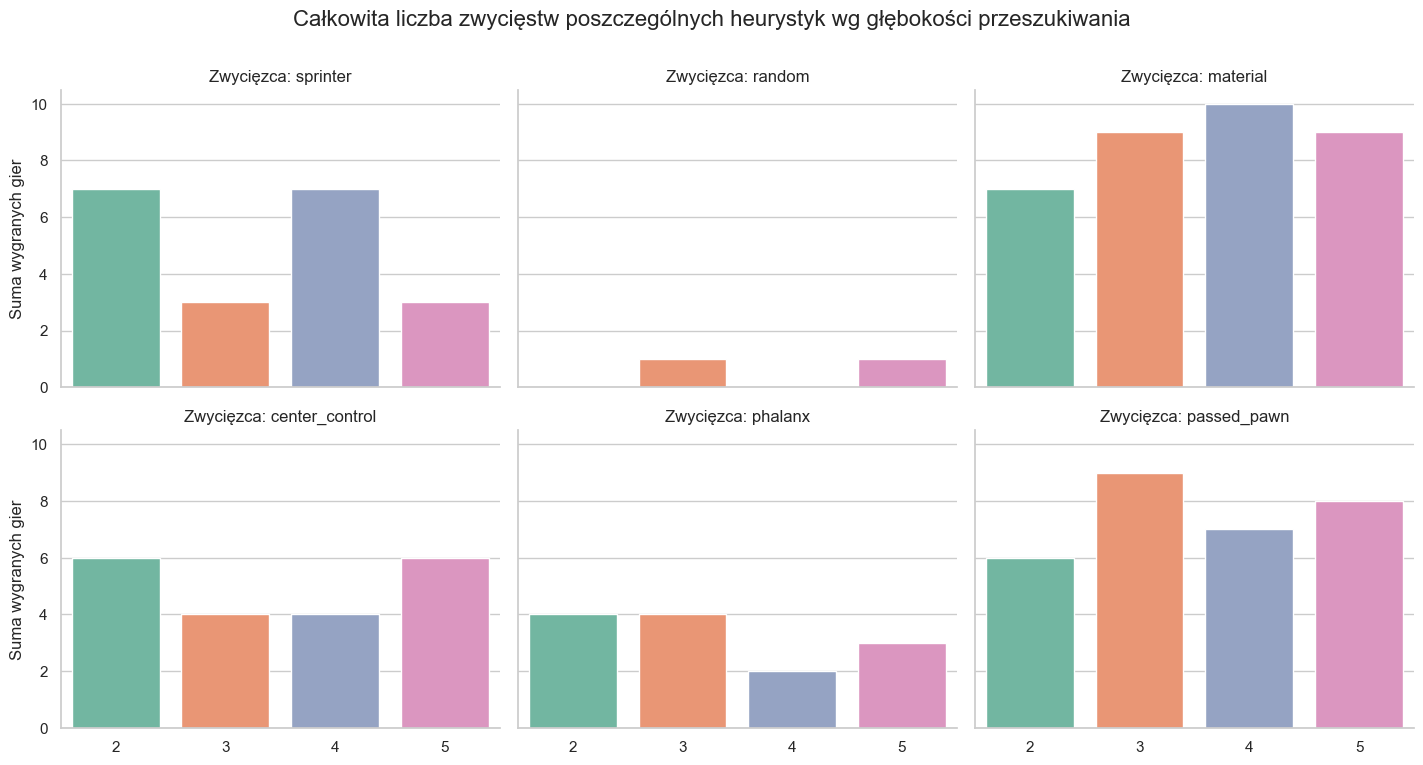

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('base_heur_safe.csv')

df['depth'] = df['player1_search_depth']

sns.set_theme(style="whitegrid")

g = sns.catplot(
    data=df,
    col='winner_heuristic',    
    col_wrap=3,                
    x='depth',                 
    kind='count',              
    palette='Set2',            
    order=[2, 3, 4, 5],        
    height=4,
    aspect=1.2
)

# 4. Kosmetyka i etykiety
g.set_axis_labels("", "Suma wygranych gier")
g.set_titles("Zwycięzca: {col_name}")
g.fig.subplots_adjust(top=0.88)
g.fig.suptitle('Całkowita liczba zwycięstw poszczególnych heurystyk wg głębokości przeszukiwania', fontsize=16)

plt.show()

Niezależnie najsilniejsza okazała się heurystyka materialna. Heurystki pozycjne osiągnęły nieco gorsze wyniki ze względu na to że same w sobie premiują idea prowadzące to zyskania przewagi, to w ostatecznym rozrachunku Breakthrough jest grą wyścigową. Ciekawym natomiast jest fakt, że losowy zawodnik również osiągnął 2 zwycięstwa: 
- `2026-04-13T18:55:10.328706,B,random,82,8,8,B,RPlayer,B,random,5,0,CPlayer,W,sprinter,5,451933,0.671246500000052s`
- `2026-04-13T18:55:09.079880,B,random,108,8,8,B,RPlayer,B,random,3,0,CPlayer,W,sprinter,3,26656,0.16148199999997814s`

Obydwa zwycięstwa odnotowane zostały przeciwko sprinterowi, który gra z pozycji białych i w obydwu grach partie trwała znaczą liczbę ruchów. Powtarzałem eksperyment jeszcze kilkukrotnie i weryfikowałem kod, ale wyniki były  powtarzalne- random wygrywał tylko z pozycji czarnych (drugiego gracza) a nawet gdy sprinter wygrywał mecz zazwyczaj trwał on około 100 ruchów. O ile samo zachowanie można było jeszcze mniej więcej zrozumieć analizując partię (losowy zawodnik dostawał się na ostatnie polę co powodowało, że sprinter się poddawał oraz to że sprinter bał się utraty swojego wyprowadzonego piona co powodowało paraliż), jednak zaskakujące był fakt że wygrane randoma zachodziły tylko z perspektywy drugiego gracza, a sam sprinter grał zupełnie inaczej przeciwko randomowi w zależności od strony. W końcu udało się znaleźć przyczynę tego zachowania: powodem była kolejność przeszukiwania listy przy generowaniu nowych ruchów- sprinter podobnie oceniał pozycje wypychające lidera jak i wykonujące ruchy z tyłu, ponieważ przewidywał zbicie lidera, jednak w przy remisie brana była pod uwagę pierwsza wygenerowana pozycja co skutkowało skrajną agresją lub pasywnością w zależności od strony. Przy iteracji odwrotnej dostawaliśmy odwrotny efekt i czarny Sprinter zaczynał się bać  

Test pruningu 

In [23]:
def test_alpha_beta_pruning(players):
    players[1].configure(sprinter_heuristic, 'sprinter', 4, True)
    players[2].configure(material_heuristic, 'material', 4, True)
    logger = MatchResultsCsvWriter('pruning.csv', append=True)
    game= Game(8,8,player1=players[1], player2=players[2], results_logger=logger)
    game.play_game(csv_data=True)
    game.p1.configure(sprinter_heuristic, 'sprinter', 4, False)
    game.p2.configure(material_heuristic, 'material', 4, False)
    game.reset_game()
    game.play_game(csv_data=True)

test_alpha_beta_pruning(players)

C:\Users\mikka\AppData\Local\Temp\ipykernel_21392\468139175.py:184: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),


In [40]:
df = pd.read_csv('pruning.csv')
df['pruning'] = ['on', 'off', 'on', 'off']
print(df[["player1_search_depth", "player1_positions_evaluated", "time_played", 'pruning']])

   player1_search_depth  player1_positions_evaluated          time_played  \
0                     5                       263430  12.483476600000358s   
1                     5                    196888253  4072.1580736999986s   
2                     4                       188542   4.049714699998731s   
3                     4                     12515818  229.20468260000052s   

  pruning  
0      on  
1     off  
2      on  
3     off  


Jak możemy zauważy wprowadzenie alfa-beta pruningu znacznie przyspiesza, działanie algorytmu. Nawet dla małych głębokości przeszukiwania różnica jest zauważalna, ale dopiero przy wyższych głębokościach przeszukiwanego drzewa jesteśmy w stanie zobaczyć jak znacznie przyspiesza to nasz algorytm. 

Agorytm dynamiczny 

Heurystyka dynamiczna wykorzystuje liczbę pionków do określenia, tego jaka strategia powinna być stosowana. Obecna implemtacja wykorzystuje każdą z napisanych heurystyk dodatkowo dzieli grę na 3 etapy (Czyli łącznie 15 wag). Funkcja została opakowana w fabrykę, ponieważ do ustalenia wag zostały użyty algorytm genetyczny. Uzyskane wagi: 
- `[0.2141, 0.2019, 0.1856, 0.1971, 0.2013, 0.3810, 0.1787, 0.2249, 0.0000, 0.2154, 0.0308, 0.1321, 0.2184, 0.3710, 0.2477]`

In [ ]:

weights = [0.2141, 0.2019, 0.1856, 0.1971, 0.2013, 0.3810, 0.1787, 0.2249, 0.0000, 0.2154, 0.0308, 0.1321, 0.2184, 0.3710, 0.2477]


dynamic = heuristic_factory(weights=weights)
final_player  = CPlayer()


def showdown(depth: int, output):
    final_player.configure(dynamic, "dynamic_function", depth, alfa_beta=True)
    for entry in players[1:]: 
        entry.search_depth = depth
        entry.alfa_beta = True

    for entry in players:
        run_match_series(final_player, entry, 2, output, 8,8, False)


showdown(4, 'final_showdown.csv')
showdown(2, 'final_showdown2.csv')


C:\Users\mikka\AppData\Local\Temp\ipykernel_21392\468139175.py:184: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),


C:\Users\mikka\AppData\Local\Temp\ipykernel_21392\2490521946.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


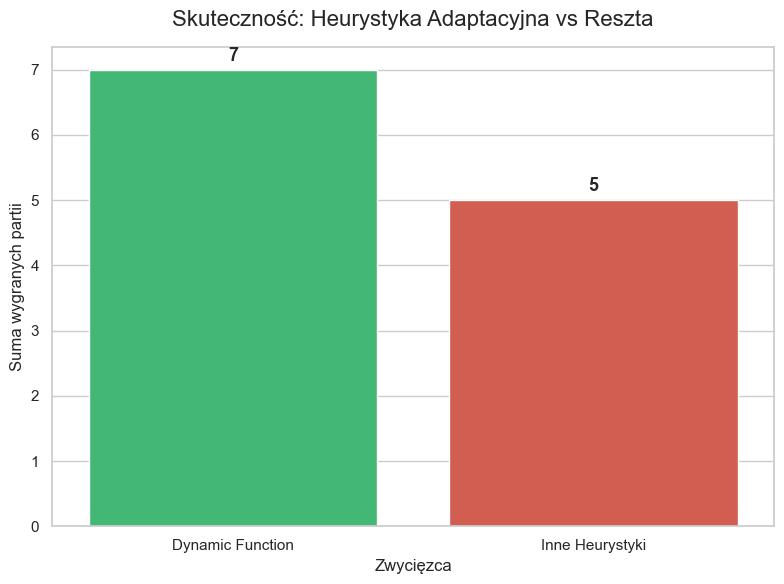

In [33]:

def plot_final_res(input: str):
    df = pd.read_csv(input)


    df['kategoria_zwyciezcy'] = df['winner_heuristic'].apply(
        lambda x: 'Dynamic Function' if x == 'dynamic_function' else 'Inne Heurystyki'
    )

    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(8, 6))

    ax = sns.countplot(
        data=df,
        x='kategoria_zwyciezcy',
        palette=['#2ecc71', '#e74c3c'], 
        order=['Dynamic Function', 'Inne Heurystyki'] 
    )

    plt.title('Skuteczność: Heurystyka Adaptacyjna vs Reszta', fontsize=16, pad=15)
    plt.xlabel('Zwycięzca', fontsize=12)
    plt.ylabel('Suma wygranych partii', fontsize=12)

    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 10), 
                    textcoords='offset points',
                    fontsize=13, fontweight='bold')

    plt.tight_layout()
    plt.show()
plot_final_res('final_showdown.csv')

C:\Users\mikka\AppData\Local\Temp\ipykernel_21392\2490521946.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


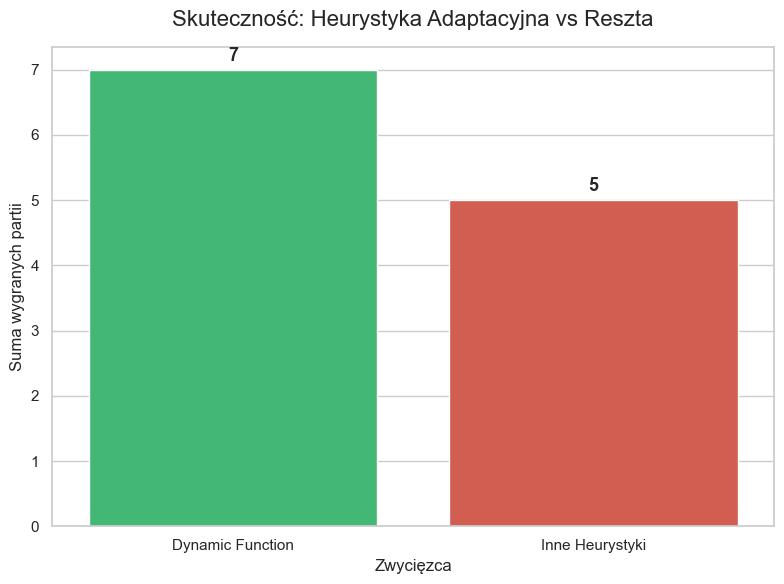

In [34]:
plot_final_res('final_showdown2.csv')

Końcowo huerystyka dynamiczna, poległa w starciu z częścią bazowych heurystyk. Zarówno dla wysokiej głębokości jak i dla niskiej głębokości, na której była trenowana otrzymaliśmy podobne rezultaty, z minimalnymi roźnicami, dla dokładniejszego treningu otrzymane rezulaty byłyby z pewnością lepsze, ale w mojej implementacji nawet wykorzystanie `PyPy`, nie przyrównuje się do hiperzoptymalizowanej wersji, napisanej w bardziej odpowiednim języku. Z perpektywy czasu, wydaje mi się że język trochę mnie ograniczył, wybierając język pokroju C++ byłbym w stanie przeprowadzić testy na większych głebokościach oraz pozwolić sobie na dłuższe bardziej dokładne szkolenie.  